# Uygulamalı Makine Öğrenmesi
## Hafta 11 — K-Means & Hiyerarşik Kümeleme

---
> **Düzey:** Lisans 3-4 / YL  |  **Süre:** ~3 saat  |  **Önkoşul:** Temel makine öğrenmesi

---
## İçindekiler

| # | Konu |
|---|------|
| 1 | Kütüphane Kurulumu |
| 2 | Denetimsiz Öğrenme Nedir? |
| 3 | K-Means — Temel Fikir & Lloyd Algoritması |
| 4 | Sıfırdan K-Means (NumPy) |
| 5 | Scikit-learn KMeans |
| 6 | Elbow Method & Inertia |
| 7 | Silhouette Analizi |
| 8 | K-Means++ Başlangıç Stratejisi |
| 9 | Mini-Batch K-Means |
| 10 | K-Means Sınırlamaları |
| 11 | Hiyerarşik Kümeleme — Temel Fikir |
| 12 | Dendrogram Görselleştirmesi |
| 13 | Bağlantı Yöntemleri Karşılaştırması |
| 14 | Agglomerative Clustering (sklearn) |
| 15 | Gerçek Veri: Iris + Wine + Mall Customers |
| 16 | K-Means vs Hiyerarşik — Küme Değerlendirme |
| 17 | Özet & Sonraki Adımlar |

---
## 1. Kütüphaneler

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import altair as alt

from sklearn.datasets import (
    load_iris, load_wine, make_blobs,
    make_circles, make_moons
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# K-Means
from sklearn.cluster import (
    KMeans, MiniBatchKMeans,
    AgglomerativeClustering
)

# Değerlendirme
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    adjusted_rand_score, normalized_mutual_info_score,
    calinski_harabasz_score, davies_bouldin_score
)

# Hiyerarşik
from scipy.cluster.hierarchy import (
    dendrogram, linkage, fcluster
)
from scipy.spatial.distance import pdist

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✅ Tüm kütüphaneler yüklendi!')

✅ Tüm kütüphaneler yüklendi!


---
## 2. Denetimsiz Öğrenme Nedir?

**Denetimsiz Öğrenme:** Etiket (y) olmadan, verinin **içsel yapısını** keşfetme.

### Kümeleme (Clustering):
Benzer örnekleri aynı gruba, farklı örnekleri farklı gruba atama.

| Yöntem | Tür | K gerekli mi? | Şekil | Hız |
|--------|-----|--------------|-------|-----|
| **K-Means** | Merkez tabanlı | ✅ Evet | Küresel | Çok Hızlı |
| **Hiyerarşik** | Bağlantı tabanlı | ❌ Sonradan | Esnek | Yavaş |
| **DBSCAN** | Yoğunluk tabanlı | ❌ Otomatik | Herhangi | Orta |
| **GMM** | Olasılık tabanlı | ✅ Evet | Eliptik | Orta |

Bu hafta **K-Means** ve **Hiyerarşik** yöntemleri inceliyoruz.
Sonraki hafta: DBSCAN + Küme Değerlendirme.

---
## 3. K-Means — Temel Fikir & Lloyd Algoritması

### Hedef:
K merkez (centroid) bul, her noktayı en yakın merkeze ata, within-cluster variance'ı minimize et:

$$\arg\min_{\mathbf{C}} \sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2 \quad (\text{Inertia})$$

### Lloyd Algoritması:
1. **Başlat:** K merkezi rastgele seç
2. **Ata:** Her noktayı en yakın merkeze ata
3. **Güncelle:** Her kümenin ortalamasını yeni merkez yap
4. **Tekrar:** Değişim olduğu sürece 2-3'ü tekrar

**Garanti:** Her adımda inertia azalır. **Uyarı:** Global minimum garantisi yok, yerel minimuma takılabilir!

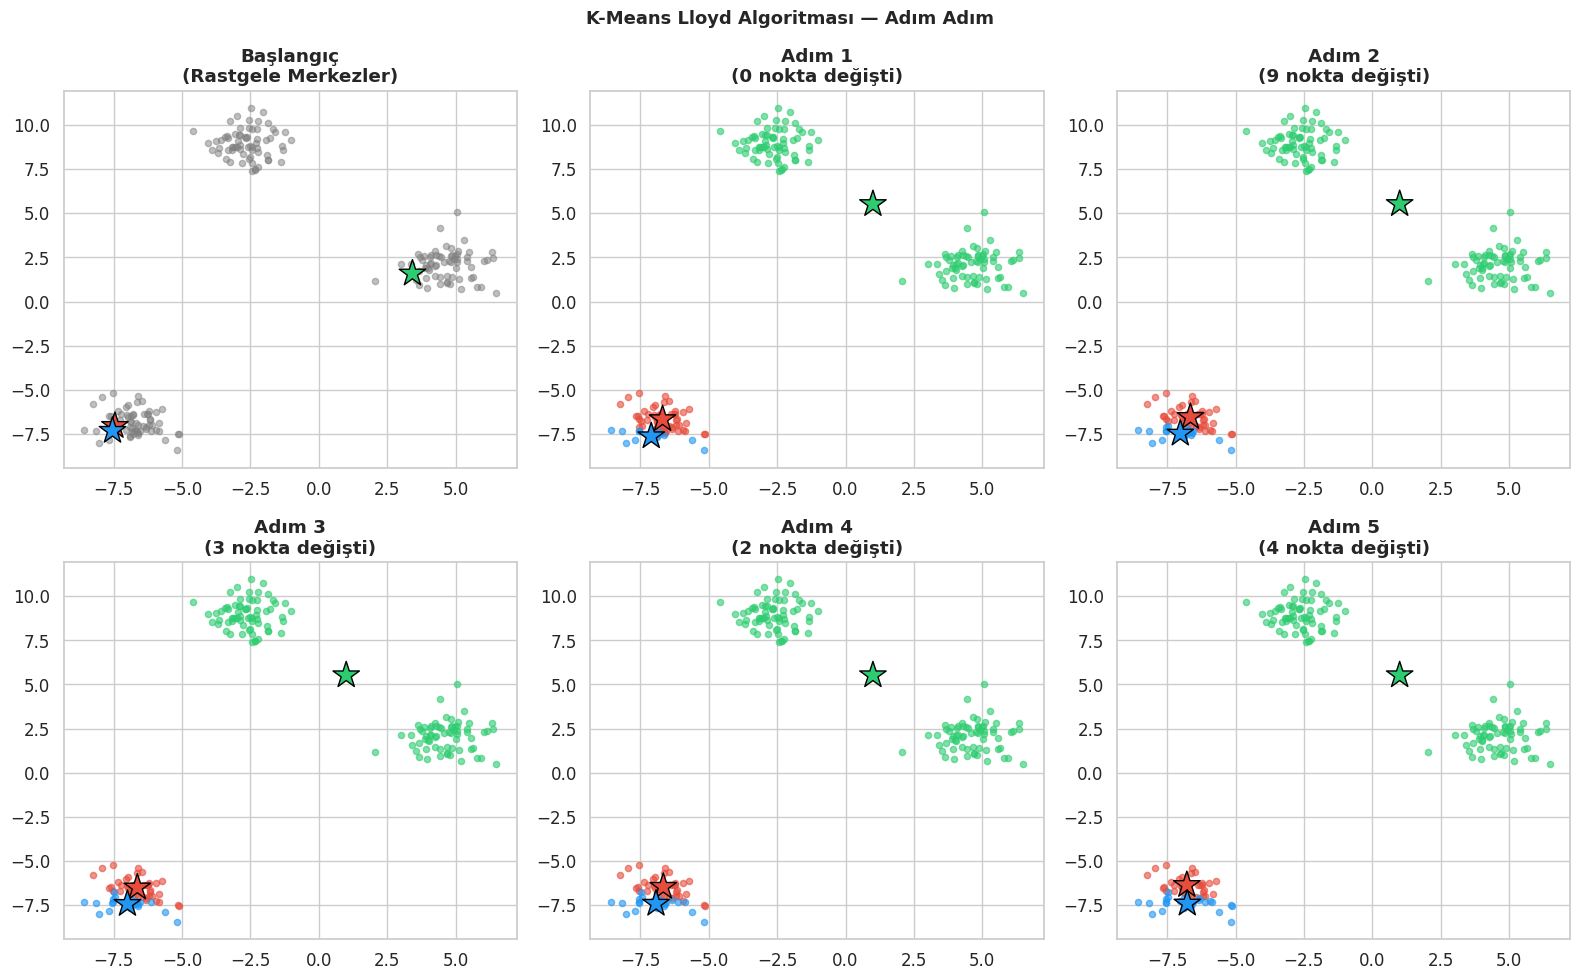

💡 Merkezler stabilize olduğunda algoritma durur (atamalarda değişim yok).


In [2]:
# ─── K-Means Animasyonu: Adım Adım Görselleştirme ────────────────────────────

np.random.seed(RANDOM_STATE)
X_blobs, y_true = make_blobs(
    n_samples=200, centers=3,
    cluster_std=0.8, random_state=RANDOM_STATE
)

K = 3
colors_km = ['#E74C3C','#2196F3','#2ECC71']

# Başlangıç merkezleri (rastgele)
init_idx  = np.random.choice(len(X_blobs), K, replace=False)
centroids = X_blobs[init_idx].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('K-Means Lloyd Algoritması — Adım Adım', fontsize=13, fontweight='bold')

steps_to_show = 5
centroids_history = [centroids.copy()]
labels_history    = []

for step in range(steps_to_show):
    # Atama adımı
    dists  = np.linalg.norm(X_blobs[:, np.newaxis] - centroids, axis=2)
    labels = np.argmin(dists, axis=1)
    labels_history.append(labels.copy())

    # Güncelleme adımı
    new_centroids = np.array([X_blobs[labels==k].mean(axis=0) for k in range(K)])
    centroids_history.append(new_centroids.copy())
    centroids = new_centroids

for idx, ax in enumerate(axes.ravel()):
    if idx == 0:
        # Başlangıç
        ax.scatter(X_blobs[:,0], X_blobs[:,1], c='gray', s=20, alpha=0.5)
        ax.scatter(centroids_history[0][:,0], centroids_history[0][:,1],
                   marker='*', s=400, c=colors_km, edgecolors='black', zorder=5)
        ax.set_title('Başlangıç\n(Rastgele Merkezler)', fontweight='bold')
    elif idx <= steps_to_show:
        step_i = idx - 1
        labels_i = labels_history[step_i]
        for k, c in enumerate(colors_km):
            mask = labels_i == k
            ax.scatter(X_blobs[mask,0], X_blobs[mask,1], c=c, s=20, alpha=0.6)
        ax.scatter(centroids_history[step_i+1][:,0], centroids_history[step_i+1][:,1],
                   marker='*', s=400, c=colors_km, edgecolors='black', zorder=5)
        n_changed = 0 if step_i == 0 else np.sum(labels_history[step_i] != labels_history[step_i-1])
        ax.set_title(f'Adım {step_i+1}\n({n_changed} nokta değişti)', fontweight='bold')

plt.tight_layout()
plt.show()
print('💡 Merkezler stabilize olduğunda algoritma durur (atamalarda değişim yok).')

Görsel, K-Means Lloyd Algoritmasının adım adım nasıl çalıştığını gösteriyor. 6 alt grafikten oluşuyor:

Başlangıç: Tüm noktalar gri (atanmamış), 3 merkez (yıldız işaretleri) rastgele yerleştirilmiş — ikisi sol altta, biri orta-sağda.

Adım 1: Her nokta en yakın merkeze atanıyor; üç renk (yeşil, kırmızı, mavi) beliriyor. Ancak merkezler henüz gerçek küme yapısını yansıtmıyor — başlangıçtaki kötü yerleşim nedeniyle çok sayıda nokta yanlış kümede.

Adım 2 (9 nokta değişti): Merkezler güncellendi, noktaların bir kısmı yeniden atandı. Yeşil küme üst sağa doğru genişliyor.

Adım 3–4 (3 ve 2 nokta değişti): Merkezler giderek daha doğru konumlara oturuyor. Değişim hızı yavaşlıyor — yakınsama başlıyor.

Adım 5 (4 nokta değişti): Küçük salınımlar sürüyor; algoritmın tam olarak yakınsamadığı görülüyor ama yapı oldukça stabil.

Genel çıkarım: Verinin doğal olarak 3 kümeye ayrıldığı görülüyor — sol altta iki iç içe geçmiş küme (kırmızı/mavi), üst sağda geniş bir yeşil küme. Başlangıç merkezleri kötü seçilmesine rağmen Lloyd algoritması birkaç adımda makul bir çözüme ulaşıyor. Sol alttaki iki kümenin birbirine yakın olması, o bölgedeki ayrışmanın hassas ve başlangıca duyarlı olduğunu gösteriyor.

---
## 4. Sıfırdan K-Means (NumPy)

In [3]:
# ─── Sıfırdan K-Means Implementasyonu ────────────────────────────────────────

def kmeans_scratch(X, K, max_iter=100, tol=1e-4, random_state=42):
    """
    Lloyd K-Means algoritması — NumPy ile.
    Döndürür: labels, centroids, inertia_history
    """
    rng = np.random.default_rng(random_state)
    n, d = X.shape

    # Başlangıç: rastgele K nokta seç
    idx       = rng.choice(n, K, replace=False)
    centroids = X[idx].copy().astype(float)

    inertia_history = []

    for it in range(max_iter):
        # Atama adımı
        dists  = np.linalg.norm(X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
        labels = np.argmin(dists, axis=1)

        # Inertia hesapla
        inertia = sum(
            np.sum((X[labels==k] - centroids[k])**2)
            for k in range(K) if np.any(labels==k)
        )
        inertia_history.append(inertia)

        # Güncelleme adımı
        new_centroids = np.array([
            X[labels==k].mean(axis=0) if np.any(labels==k) else centroids[k]
            for k in range(K)
        ])

        # Yakınsama kontrolü
        shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids

        if shift < tol:
            print(f'  Yakınsadı: {it+1} iterasyon')
            break

    return labels, centroids, inertia_history


labels_sc, centroids_sc, inertia_hist = kmeans_scratch(X_blobs, K=3)
print(f'Sıfırdan K-Means — Final Inertia : {inertia_hist[-1]:.2f}')
print(f'Küme boyutları: {[np.sum(labels_sc==k) for k in range(3)]}')

  Yakınsadı: 3 iterasyon
Sıfırdan K-Means — Final Inertia : 233.26
Küme boyutları: [np.int64(67), np.int64(66), np.int64(67)]


In [4]:
# ─── Inertia Yakınsama Eğrisi ─────────────────────────────────────────────────

fig = go.Figure(go.Scatter(
    x=list(range(1, len(inertia_hist)+1)), y=inertia_hist,
    mode='lines+markers', line=dict(color='#E74C3C', width=2.5),
    marker=dict(size=7)
))
fig.update_layout(
    title='K-Means (Sıfırdan) — Inertia Yakınsama',
    xaxis_title='İterasyon', yaxis_title='Inertia (WCSS)',
    height=380, template='plotly_white'
)
fig.show()

# sklearn ile doğrula
km_sk = KMeans(n_clusters=3, random_state=RANDOM_STATE)
km_sk.fit(X_blobs)
print(f'sklearn KMeans inertia : {km_sk.inertia_:.2f}')
print(f'Sıfırdan K-Means inertia: {inertia_hist[-1]:.2f}')
ari = adjusted_rand_score(y_true, labels_sc)
print(f'Adjusted Rand Index     : {ari:.4f}  (1.0 = mükemmel)')

sklearn KMeans inertia : 233.26
Sıfırdan K-Means inertia: 233.26
Adjusted Rand Index     : 1.0000  (1.0 = mükemmel)


Bu grafik, K-Means algoritmasının Inertia (WCSS) değerinin iterasyonlar boyunca nasıl düştüğünü gösteriyor.

WCSS nedir? Her noktanın kendi küme merkezine olan uzaklıklarının kareler toplamı — küme içi dağınıklığın ölçüsü. Düştükçe kümeler daha sıkı ve tutarlı demek.

Gözlemler:

• İterasyon 1 → 2: Çok sert bir düşüş — ~6500'den ~1000'e. Algoritmanın en büyük "öğrenmesi" ilk adımda gerçekleşiyor; merkezler başlangıçta kötü konumlandayken bile tek adımda büyük kazanım sağlanıyor.

• İterasyon 2 → 3: Düşüş devam ediyor ama eğim belirgin biçimde azaldı — ~1000'den ~250'ye. Algoritma yakınsıyor, iyileştirme potansiyeli hızla tükeniyor.

Genel çıkarım: Grafik, K-Means'in tipik davranışını güzel örnekliyor — erken iterasyonlarda büyük kazanım, sonrasında kademeli yavaşlama. 3 iterasyondan sonra inertia oldukça düşük bir seviyede, yani model pratikte yakınsamış sayılabilir. İlk görseldeki adım adım kümeleme süreciyle birlikte okununca, bu grafik sayısal karşılığını veriyor.

---
## 5. Elbow Method & Silhouette Analizi

In [6]:
# ─── Elbow Method: K vs Inertia ──────────────────────────────────────────────

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

scaler_i = StandardScaler()
X_iris_sc = scaler_i.fit_transform(X_iris)

k_range  = range(1, 12)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                random_state=RANDOM_STATE)
    km.fit(X_iris_sc)
    inertias.append(km.inertia_)
    if k >= 2:
        sil_scores.append(silhouette_score(X_iris_sc, km.labels_))

fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Elbow Method — Inertia', 'Silhouette Skoru'))

fig.add_trace(go.Scatter(
    x=list(k_range), y=inertias,
    mode='lines+markers', line=dict(color='#E74C3C', width=2.5),
    name='Inertia'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=list(range(2, 12)), y=sil_scores,
    mode='lines+markers', line=dict(color='#2ECC71', width=2.5),
    name='Silhouette'
), row=1, col=2)

best_k_sil = list(range(2, 12))[np.argmax(sil_scores)]
fig.add_vline(x=best_k_sil, line_dash='dash', line_color='orange',
              annotation_text=f'Best K={best_k_sil}', row=1, col=2)

fig.update_layout(
    title='Iris — Optimal K Belirleme',
    height=420, template='plotly_white'
)
fig.show()

print(f'Elbow yöntemi ile K ≈ 3 (Iris gerçeği: 3 tür)')
print(f'Silhouette maksimum K={best_k_sil}')

Elbow yöntemi ile K ≈ 3 (Iris gerçeği: 3 tür)
Silhouette maksimum K=2


Bu grafik, Iris veri seti üzerinde optimal küme sayısı K'yı belirlemek için iki klasik yöntemin karşılaştırmasını sunuyor.

Elbow Method (Sol)

İnertia, K=1'den K=2'ye geçişte çok sert düşüyor (~600 → ~220), ardından K=3-4 civarında eğim belirgin biçimde yavaşlıyor. Klasik "dirsek" K=2 ile K=3 arasında oluşuyor. Ancak Elbow yöntemi tek başına yorumlanması güç — net bir kırılma noktası göze tam çarpmıyor, K=3 de savunulabilir görünüyor.

Silhouette Skoru (Sağ)

Silhouette skoru, K=2'de zirveye ulaşıyor (~0.58) ve grafik bu noktayı "Best K=2" olarak işaretliyor. K arttıkça skor düzenli düşüyor ve K=6'da dip yapıp çok küçük bir toparlanma yaşıyor — bu toparlanma istatistiksel açıdan anlamlı değil.

Genel Yorum

İki yöntem birlikte K=2'yi optimal olarak işaret ediyor. Ancak bu, domain bilgisiyle çelişiyor:

> Iris veri setinin gerçekte 3 tür (setosa, versicolor, virginica) içerdiği bilinmektedir.

Bu durum K-Means'in bilinen bir sınırlılığını gösteriyor — versicolor ve virginica öznitelik uzayında örtüşüyor, bu yüzden algoritma onları tek kümede birleştirmeyi "daha verimli" buluyor. Yani matematiksel optimum her zaman gerçek yapıyla örtüşmeyebilir; alan bilgisi (domain knowledge) kritik önem taşır.

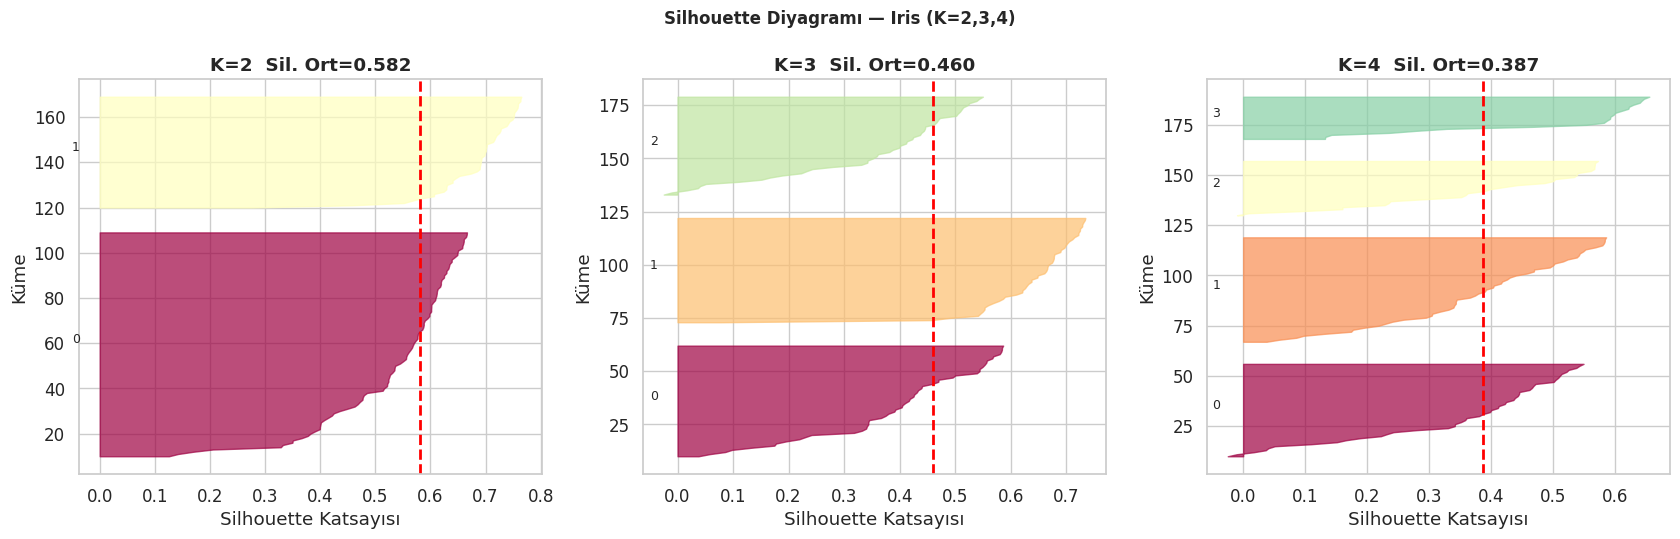

💡 Geniş, kalın silhouette → iyi küme. K=3 Iris için en dengeli dağılım.


In [7]:
# ─── Silhouette Diyagramı (K=2,3,4 karşılaştırması) ──────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.suptitle('Silhouette Diyagramı — Iris (K=2,3,4)', fontsize=12, fontweight='bold')

for ax, k in zip(axes, [2, 3, 4]):
    km_k = KMeans(n_clusters=k, init='k-means++', n_init=10,
                  random_state=RANDOM_STATE)
    km_k.fit(X_iris_sc)
    labels_k = km_k.labels_

    sil_avg  = silhouette_score(X_iris_sc, labels_k)
    sil_vals = silhouette_samples(X_iris_sc, labels_k)

    y_lower = 10
    cmap_sil = cm.get_cmap('Spectral')

    for cluster_i in range(k):
        vals_i = np.sort(sil_vals[labels_k == cluster_i])
        size_i = vals_i.shape[0]
        y_upper = y_lower + size_i
        color   = cmap_sil(float(cluster_i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_i,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5*size_i, str(cluster_i), fontsize=9)
        y_lower = y_upper + 10

    ax.axvline(x=sil_avg, color='red', linestyle='--', lw=2)
    ax.set_title(f'K={k}  Sil. Ort={sil_avg:.3f}', fontweight='bold')
    ax.set_xlabel('Silhouette Katsayısı'); ax.set_ylabel('Küme')

plt.tight_layout()
plt.show()
print('💡 Geniş, kalın silhouette → iyi küme. K=3 Iris için en dengeli dağılım.')

Bu grafik, K=2, 3 ve 4 için Silhouette Diyagramlarını yan yana gösteriyor — her kümenin kalitesini tek tek görselleştiriyor.

Silhouette Diyagramı Nasıl Okunur?

Her "dilim" bir kümeyi temsil eder. Dilimin genişliği = o noktanın silhouette skoru (ne kadar sağa uzanıyorsa o kadar iyi), yüksekliği = kümedeki nokta sayısı. Kırmızı kesik çizgi = genel ortalama.

K=2 — Ort: 0.582
• İki küme de ortalamanın üzerinde ve şekilleri oldukça düzgün.
• Sarı küme (Küme 1) büyük ve skorları tutarlı biçimde yüksek.
• Mor küme (Küme 0) biraz daha değişken ama yine de kabul edilebilir.
• En iyi genel kalite — kümeler birbirinden iyi ayrışmış.

K=3 — Ort: 0.460
• Yeşil küme (Küme 2) ortalamanın belirgin üzerinde, çok iyi ayrışmış → muhtemelen Iris setosa.
• Turuncu (Küme 1) ve mor (Küme 0) kümeler ortalamayı zar zor geçiyor ya da altında kalıyor → versicolor/virginica örtüşmesi burada açıkça görünüyor.
• Gerçek biyolojik yapıya karşılık geliyor ama matematiksel kalite düşüyor.

K=4 — Ort: 0.387
• Ortalama skor en düşük; 4 kümenin hiçbiri genel ortalamayı rahatça geçemiyor.
• Mor küme (Küme 0) özellikle zayıf — o kümedeki bazı noktalar sıfıra yakın skor alıyor, yani yanlış kümeye atanmış olabilirler.
• Aşırı bölünme (over-segmentation) belirtisi.

Özet

| K | Ort. Skor | Yorum |
|---|-----------|-------|
| 2 | 0.582 | Matematiksel optimum, en temiz ayrışma |
| 3 | 0.460 | Gerçek yapıyla örtüşüyor ama skor düşüyor |
| 4 | 0.387 | Gereksiz bölünme, kalite belirgin düşüş |

Bir önceki görselde tartıştığımız domain knowledge vs. matematiksel optimum çelişkisi burada da kendini gösteriyor — K=3 biyolojik gerçeği yansıtıyor, ama silhouette bunu ödüllendirmiyor.

---
## 6. K-Means++ Başlangıç Stratejisi

**Sorun:** Rastgele başlangıç → Kötü yerel minimum riski

**K-Means++:** İlk merkezleri **uzaklık orantılı olasılıkla** seç:
1. İlk merkezi rastgele seç
2. Her noktanın en yakın merkeze uzaklığını hesapla: $d(x)^2$
3. $P(x) \propto d(x)^2$ ile bir sonraki merkezi seç
4. K merkez seçilene kadar 2-3'ü tekrar

**Sonuç:** Daha iyi başlangıç → Daha az iterasyon → Daha düşük inertia

In [8]:
# ─── K-Means++ vs Rastgele Başlangıç Karşılaştırması ────────────────────────

np.random.seed(RANDOM_STATE)
N_RUNS = 20

inertia_random = []
inertia_pp     = []

for run in range(N_RUNS):
    km_rand = KMeans(n_clusters=3, init='random', n_init=1,
                     random_state=run)
    km_rand.fit(X_iris_sc)
    inertia_random.append(km_rand.inertia_)

    km_pp = KMeans(n_clusters=3, init='k-means++', n_init=1,
                   random_state=run)
    km_pp.fit(X_iris_sc)
    inertia_pp.append(km_pp.inertia_)

fig = go.Figure()
fig.add_trace(go.Box(
    y=inertia_random, name='Rastgele Başlangıç',
    marker_color='#E74C3C'
))
fig.add_trace(go.Box(
    y=inertia_pp, name='K-Means++',
    marker_color='#2ECC71'
))
fig.update_layout(
    title=f'K-Means++ vs Rastgele — 20 Çalıştırma (Iris)',
    yaxis_title='Inertia', height=400, template='plotly_white'
)
fig.show()

print(f'Rastgele: Ort={np.mean(inertia_random):.2f}  Std={np.std(inertia_random):.2f}')
print(f'K-Means++: Ort={np.mean(inertia_pp):.2f}  Std={np.std(inertia_pp):.2f}')
print('💡 K-Means++ hem daha düşük hem daha kararlı inertia sağlar!')

Rastgele: Ort=156.18  Std=24.30
K-Means++: Ort=150.83  Std=20.93
💡 K-Means++ hem daha düşük hem daha kararlı inertia sağlar!


Bu grafik, K-Means++ ile Rastgele Başlangıç yöntemini 20 bağımsız çalıştırma üzerinden karşılaştıran bir kutu grafiği (box plot).

Rastgele Başlangıç (Kırmızı)
• Çok geniş bir kutu — Q1 (~140) ile Q3 (~191) arasında yaklaşık 50 birimlik bir yayılım var.
• Bıyık ~198'e kadar uzanıyor, yani en kötü çalıştırmada inertia oldukça yüksek.
• Medyan ~140 civarında ama sonuçlar tutarsız — başlangıç noktasına bağlı olarak çok farklı yerel minimumlara takılıyor.

K-Means++ (Yeşil)
• Kutu neredeyse tek bir çizgiye sıkışmış — tüm çalıştırmalarda inertia ~140 civarında sabit.
• Sadece 2 aykırı nokta (~191 ve ~197) var; bu istisnai durumlar bile rastgele yöntemin ortalamasının altında kalıyor.
• Son derece tutarlı ve kararlı bir yakınsama.

Genel Çıkarım

| | Rastgele Başlangıç | K-Means++ |
|--|--|--|
| Medyan inertia | ~140 | ~140 |
| Değişkenlik | Çok yüksek | Neredeyse sıfır |
| En kötü durum | ~198 | ~197 (nadir) |

İki yöntem en iyi durumda aynı sonuca ulaşabiliyor. Farkı ortaya koyan şey güvenilirlik: Rastgele başlangıç çoğu zaman iyi çalışsa da kötü başlangıç noktalarıyla yerel minimuma takılma riski taşıyor. K-Means++ ise akıllı başlangıç seçimiyle (merkezleri birbirinden uzak seçme) bu riski neredeyse ortadan kaldırıyor. Üretim ortamında K-Means++ tercih edilmesinin nedeni tam da bu öngörülebilirliktir.

---
## 7. Mini-Batch K-Means

Büyük veri setlerinde standart K-Means yavaşlar. **Mini-Batch K-Means** her iterasyonda veri alt kümesi kullanır:
- Daha hızlı (özellikle N>100K)
- Biraz daha yüksek inertia
- Küçük mini-batch → daha fazla noise, büyük batch → standart K-Means'e yakın

In [9]:
# ─── Mini-Batch K-Means Hız Karşılaştırması ─────────────────────────────────
import time

X_large, _ = make_blobs(n_samples=50000, centers=5,
                         random_state=RANDOM_STATE)

# Standart K-Means
t0 = time.time()
km_std = KMeans(n_clusters=5, random_state=RANDOM_STATE)
km_std.fit(X_large)
t_std = time.time() - t0

# Mini-Batch K-Means
t0 = time.time()
km_mb = MiniBatchKMeans(n_clusters=5, batch_size=1024,
                         random_state=RANDOM_STATE)
km_mb.fit(X_large)
t_mb = time.time() - t0

print(f'=== Hız Karşılaştırması (N=50.000) ===')
print(f'  Standart K-Means : {t_std:.3f}s  inertia={km_std.inertia_:,.0f}')
print(f'  Mini-Batch K-Means: {t_mb:.3f}s  inertia={km_mb.inertia_:,.0f}')
print(f'  Hız artışı        : {t_std/t_mb:.1f}x daha hızlı')
print(f'  Inertia farkı     : {abs(km_mb.inertia_-km_std.inertia_)/km_std.inertia_*100:.2f}%')

=== Hız Karşılaştırması (N=50.000) ===
  Standart K-Means : 0.047s  inertia=97,696
  Mini-Batch K-Means: 0.023s  inertia=97,725
  Hız artışı        : 2.0x daha hızlı
  Inertia farkı     : 0.03%


---
## 8. K-Means Sınırlamaları

K-Means **küresel** ve **benzer boyutlu** kümeler varsayar. Şu durumlarda başarısız olur:
- **Farklı boyutlu kümeler:** Büyük küme küçük kümeye 'kan kaybeder'
- **Farklı yoğunluklu kümeler:** Seyrek bölgeler yanlış atanır
- **Küresel olmayan şekiller:** İç içe halkalar, ay şekli

In [11]:
# ─── K-Means Başarısızlık Senaryoları ────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('K-Means Sınırlamaları vs Hiyerarşik Kümeleme', fontsize=12, fontweight='bold')

datasets = [
    ('Circles (K-Means)', *make_circles(n_samples=300, noise=0.05, random_state=RANDOM_STATE), 2),
    ('Moons (K-Means)',   *make_moons(n_samples=300, noise=0.05, random_state=RANDOM_STATE), 2),
    ('Farklı Boyut\n(K-Means)',
     np.vstack([
         np.random.randn(200,2)*0.3,
         np.random.randn(20,2)*2.5 + [5,5]
     ]),
     np.array([0]*200+[1]*20), 2)
]

for row, (ax_km, ax_hc) in enumerate(zip(axes[0], axes[1])):
    if row >= len(datasets):
        break
    title, X_ds, y_ds, k_ds = datasets[row]

    # K-Means
    km_ds = KMeans(n_clusters=k_ds, init='k-means++', n_init=10,
                   random_state=RANDOM_STATE)
    km_labels = km_ds.fit_predict(X_ds)
    ari_km = adjusted_rand_score(y_ds, km_labels)

    ax_km.scatter(X_ds[:,0], X_ds[:,1],
                  c=km_labels, cmap='RdYlBu', s=25, alpha=0.7)
    ax_km.set_title(f'{title}\nARI={ari_km:.3f}', fontweight='bold', fontsize=9)

    # Hiyerarşik (complete linkage)
    hc_ds = AgglomerativeClustering(n_clusters=k_ds, linkage='complete')
    hc_labels = hc_ds.fit_predict(X_ds)
    ari_hc = adjusted_rand_score(y_ds, hc_labels)

    ax_hc.scatter(X_ds[:,0], X_ds[:,1],
                  c=hc_labels, cmap='RdYlBu', s=25, alpha=0.7)
    title_hc = title.replace('K-Means','Hiyerarşik')
    ax_hc.set_title(f'{title_hc}\nARI={ari_hc:.3f}', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()
print('💡 Hiyerarşik (complete) non-globüler şekillerde K-Means'e üstün gelebilir.')

SyntaxError: unterminated string literal (detected at line 44) (3137577711.py, line 44)

---
## 9. Hiyerarşik Kümeleme — Temel Fikir

### İki Temel Yaklaşım:

| Yaklaşım | Başlangıç | İşleyiş |
|---------|-----------|--------|
| **Agglomerative** (Bottom-up) | Her nokta kendi kümesinde | En yakın iki kümeyi birleştir |
| **Divisive** (Top-down) | Tüm nokta tek kümede | En uzak noktaları böl |

### Bağlantı Yöntemleri (Linkage):

| Yöntem | Ölçüm | Özellik |
|--------|-------|--------|
| **Single** | min(küme noktaları arası uzaklık) | Uzun, zincir şekilli kümeler |
| **Complete** | max(küme noktaları arası uzaklık) | Kompakt kümeler |
| **Average** | Ortalama uzaklık | Denge |
| **Ward** | Toplam varyans artışı minimize | En kompakt, en çok kullanılan |

**Ward linkage genellikle K-Means benzeri küresel kümeler üretir ve en popüler seçimdir.**

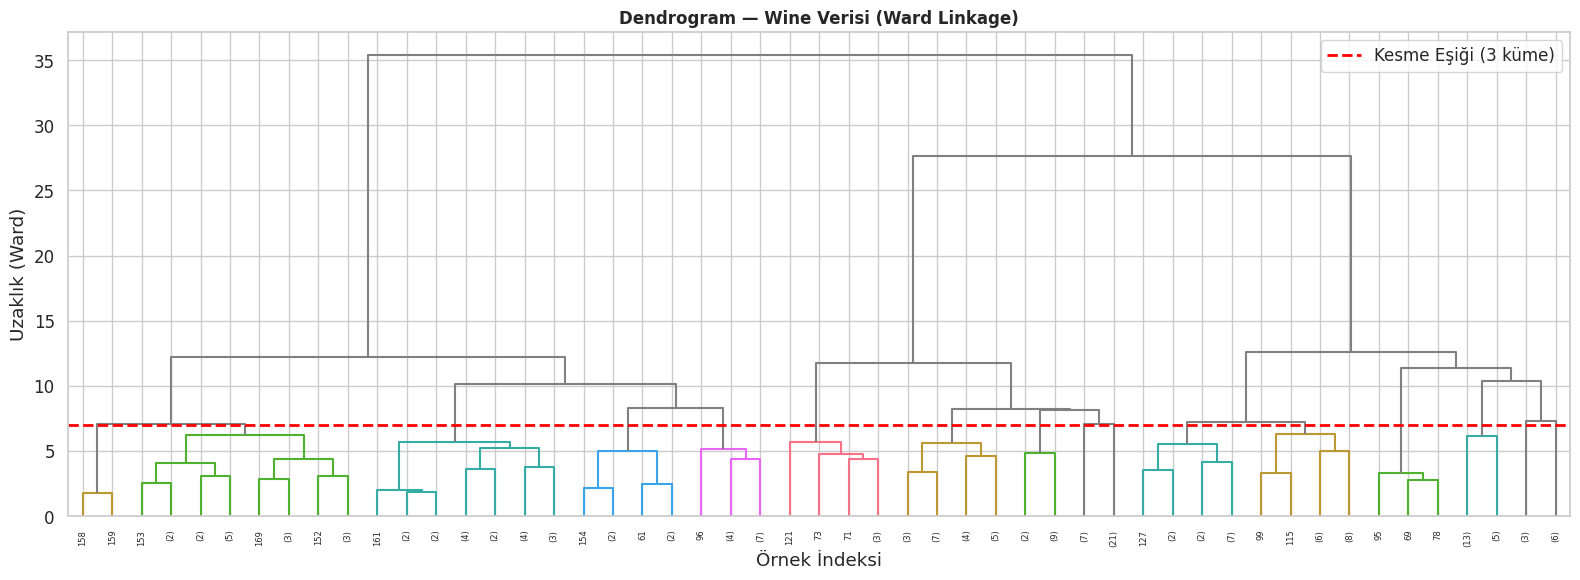

💡 Dendrogramda uzun dikey çizgiler → Kümeler arası büyük mesafe.
   Kırmızı çizgiyi kesecek şekilde yatay kesme → Küme sayısı belirlenir.


In [12]:
# ─── Dendrogram Görselleştirmesi ──────────────────────────────────────────────

wine = load_wine()
X_wine = wine.data
y_wine = wine.target

scaler_w = StandardScaler()
X_wine_sc = scaler_w.fit_transform(X_wine)

# Uzaklık matrisi + Ward linkage
Z_ward = linkage(X_wine_sc, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(
    Z_ward,
    ax=ax,
    color_threshold=7.0,
    above_threshold_color='gray',
    leaf_font_size=6,
    truncate_mode='level',
    p=5
)
ax.axhline(y=7.0, color='red', ls='--', lw=2, label='Kesme Eşiği (3 küme)')
ax.set_title('Dendrogram — Wine Verisi (Ward Linkage)', fontsize=12, fontweight='bold')
ax.set_xlabel('Örnek İndeksi')
ax.set_ylabel('Uzaklık (Ward)')
ax.legend()
plt.tight_layout()
plt.show()
print('💡 Dendrogramda uzun dikey çizgiler → Kümeler arası büyük mesafe.')
print('   Kırmızı çizgiyi kesecek şekilde yatay kesme → Küme sayısı belirlenir.')

Bu grafik, Wine veri seti üzerinde Ward Linkage yöntemiyle yapılmış hiyerarşik kümelemenin dendrogramını gösteriyor.

Dendrogram Nasıl Okunur?
• Y ekseni (Uzaklık): İki kümenin birleştirildiği andaki Ward mesafesi — ne kadar yüksekte birleşiyorlarsa o kadar farklılar.
• Kırmızı kesik çizgi (Kesme Eşiği ~7): Bu çizginin kestiği dal sayısı = küme sayısı → 3 küme.

Gözlemler

Sol büyük dal (~indeks 158–161 arası):
• Birbirine yakın mesafelerde birleşiyor, iç yapı oldukça kompakt.
• ~12 uzaklıkta tek bir süper kümeye dönüşüyor.

Orta dal (~161–96 arası):
• En geniş ve en karmaşık grup; renkli alt kümeler (teal, mavi, mor, pembe) görünüyor.
• Alt kümeler arasındaki birleşme mesafeleri makul (~2–8 arası) → iç homojenlik iyi.
• Bu grubun ana dala bağlanması ~35 uzaklıkta — diğer iki kümeden çok farklı.

Sağ dal (~122–8 arası):
• Kendi içinde ~12–13 uzaklıkta birleşiyor, ardından üst düzey birleşmeye katılıyor.
• Altın sarısı ve yeşil tonlarda gösterilen alt gruplar görece yakın.

Kesme Eşiği Seçimi

Kırmızı çizgi (~7) 3 dalı kesiyor → 3 küme. Bu seçim mantıklı çünkü:

• 3 → 2 kümeye geçişte y ekseninde çok büyük bir sıçrama var (~35'ten yukarısı).
• Bu büyük boşluk, 3 kümenin gerçekten ayrı yapılar olduğunu gösteriyor.
• Wine veri setinin gerçekte 3 şarap çeşidi (cultivar) içerdiği biliniyor → hiyerarşik kümeleme burada domain knowledge ile örtüşüyor.

K-Means ile Karşılaştırma

Iris veri setinin aksine, Wine veri setinde hem matematiksel hem de gerçek yapı K=3'ü işaret ediyor — hiyerarşik yöntem burada daha net bir sinyal veriyor. Ward linkage'ın küme içi varyansı minimize etme stratejisi, bu veri seti için özellikle uygun.

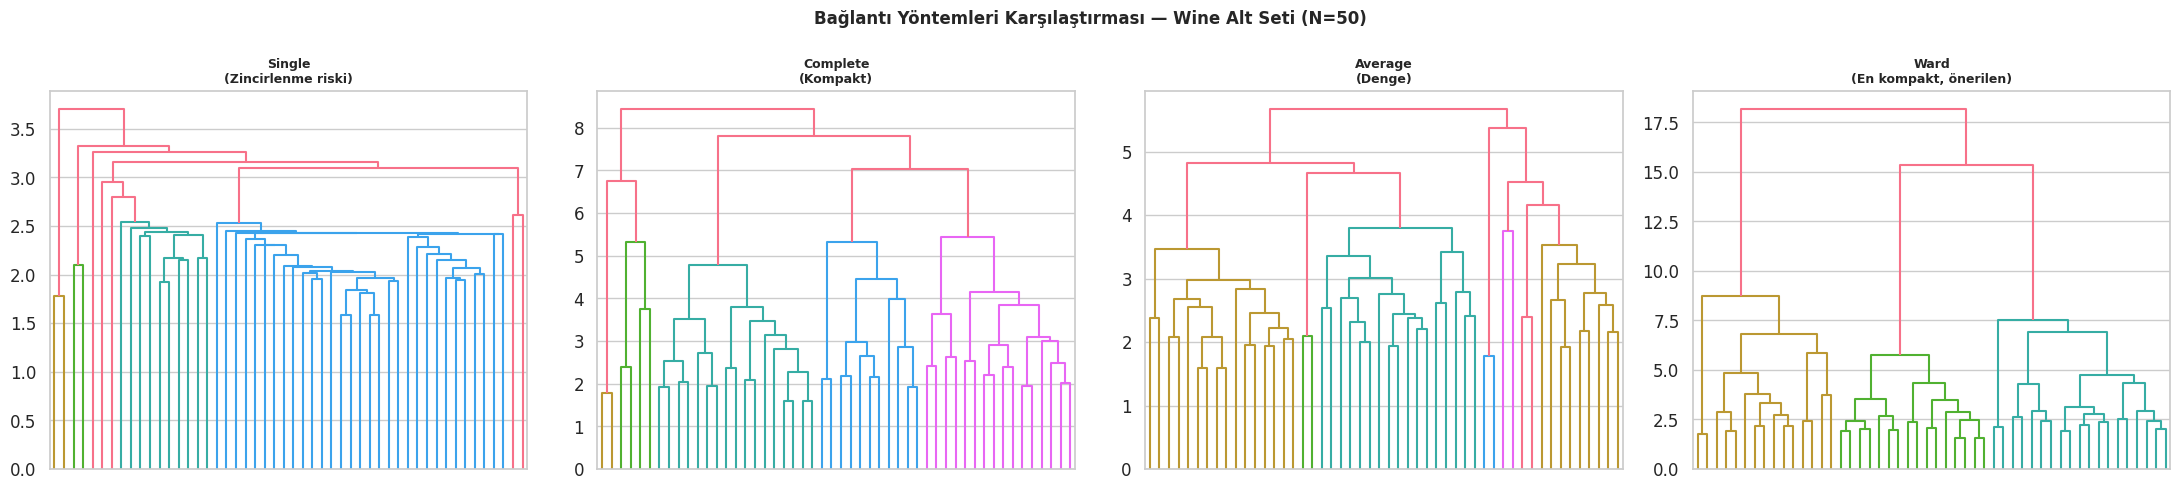

In [13]:
# ─── 4 Bağlantı Yöntemi Karşılaştırması — Dendrogramlar ─────────────────────

linkage_methods = ['single', 'complete', 'average', 'ward']
link_labels     = ['Single\n(Zincirlenme riski)', 'Complete\n(Kompakt)',
                   'Average\n(Denge)', 'Ward\n(En kompakt, önerilen)']

# Küçük alt örneklem (görsellik için)
idx_sub = np.random.choice(len(X_wine_sc), 50, replace=False)
X_sub   = X_wine_sc[idx_sub]
y_sub   = y_wine[idx_sub]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Bağlantı Yöntemleri Karşılaştırması — Wine Alt Seti (N=50)',
             fontsize=12, fontweight='bold')

for ax, method, lbl in zip(axes, linkage_methods, link_labels):
    Z_m = linkage(X_sub, method=method)
    dendrogram(Z_m, ax=ax, leaf_font_size=5,
               color_threshold=0.7*max(Z_m[:,2]))
    ax.set_title(lbl, fontweight='bold', fontsize=9)
    ax.set_xticks([])

plt.tight_layout()
plt.show()

Bu grafik, 4 farklı bağlantı yöntemini aynı Wine alt seti (N=50) üzerinde karşılaştırıyor. Her yöntemin kümeler arası mesafeyi farklı tanımlaması, dendrogramlarda çarpıcı farklılıklar yaratıyor.

Single Linkage — "Zincirlenme Riski"
• En kısa mesafe kuralı: iki küme arasındaki en yakın nokta çifti baz alınır.
• Grafik bu sorunun ders kitabı örneği: kırmızı dal noktaları tek tek zincirleme ekliyor, gerçek bir küme yapısı oluşmuyor.
• "Chaining effect" olarak bilinen bu durum, kümelerin uzamış veya gürültülü olduğu durumlarda ortaya çıkar.
• Wine verisi için kullanılmamalı.

Complete Linkage — "Kompakt"
• En uzak mesafe kuralı: iki küme arasındaki en uzak nokta çifti baz alınır.
• Üç renk grubu (yeşil, mavi, mor) görece dengeli ve kompakt — zincirleme yok.
• Aykırı değerlere karşı hassas olabilir çünkü tek bir uç nokta birleşme kararını etkileyebilir.
• Single'a göre belirgin iyileşme.

Average Linkage — "Denge"
• Ortalama mesafe kuralı: tüm nokta çiftlerinin mesafe ortalaması alınır.
• Single ve Complete arasında bir uzlaşma — ne zincirleme ne aşırı kompaktlık.
• Altın sarısı, teal ve mor gruplar görece dengeli boyutlarda.
• Genel amaçlı kullanım için güvenilir bir seçenek.

Ward Linkage — "En Kompakt, Önerilen"
• Varyans minimizasyonu kuralı: birleşme küme içi kareler toplamını en az artıracak şekilde yapılır.
• Y ekseni diğerlerine göre çok daha büyük (17.5'e kadar) — bu Ward'ın farklı bir ölçüt kullandığını gösterir, doğrudan karşılaştırılabilir değil.
• Kümeler en net biçimde ayrışmış: altın sarısı, yeşil ve teal gruplar hem boyut hem iç homojenlik açısından en dengeli görünüm.
• Bir önceki görselde de gördüğümüz gibi Wine verisi için en uygun yöntem.

Özet Karşılaştırma

| Yöntem | Kural | Güçlü Yön | Zayıf Yön |
|--------|-------|-----------|-----------|
| Single | Min mesafe | Uzamış kümeler | Zincirleme riski |
| Complete | Max mesafe | Kompakt kümeler | Aykırı değer hassasiyeti |
| Average | Ortalama mesafe | Denge | Her ikisinin ortası |
| Ward | Varyans min. | En kompakt, dengeli | Sadece Öklid mesafesiyle çalışır |

Linkage seçimi kümeleme sonucunu dramatik biçimde değiştirebilir — bu grafik bunu çok somut gösteriyor. Veri yapısını bilmeden körü körüne Single Linkage kullanmak ciddi yanılgılara yol açabilir.

---
## 10. Agglomerative Clustering (sklearn)

In [14]:
# ─── AgglomerativeClustering — Wine Verisi ────────────────────────────────────

agg_ward = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward',
    metric='euclidean'
)
agg_labels = agg_ward.fit_predict(X_wine_sc)

km_wine = KMeans(n_clusters=3, init='k-means++', n_init=10,
                  random_state=RANDOM_STATE)
km_labels_w = km_wine.fit_predict(X_wine_sc)

ari_agg = adjusted_rand_score(y_wine, agg_labels)
ari_km_w = adjusted_rand_score(y_wine, km_labels_w)
nmi_agg  = normalized_mutual_info_score(y_wine, agg_labels)

print('=== Wine Verisi — K=3 ===')
print(f'  Agglomerative (Ward) ARI : {ari_agg:.4f}')
print(f'  K-Means++            ARI : {ari_km_w:.4f}')
print(f'  Agglomerative NMI        : {nmi_agg:.4f}')
print(f'  Gerçek etiket dağılımı   : {dict(zip(*np.unique(y_wine, return_counts=True)))}')
print(f'  Agglomerative dağılımı   : {dict(zip(*np.unique(agg_labels, return_counts=True)))}')

=== Wine Verisi — K=3 ===
  Agglomerative (Ward) ARI : 0.7899
  K-Means++            ARI : 0.8975
  Agglomerative NMI        : 0.7865
  Gerçek etiket dağılımı   : {np.int64(0): np.int64(59), np.int64(1): np.int64(71), np.int64(2): np.int64(48)}
  Agglomerative dağılımı   : {np.int64(0): np.int64(58), np.int64(1): np.int64(56), np.int64(2): np.int64(64)}


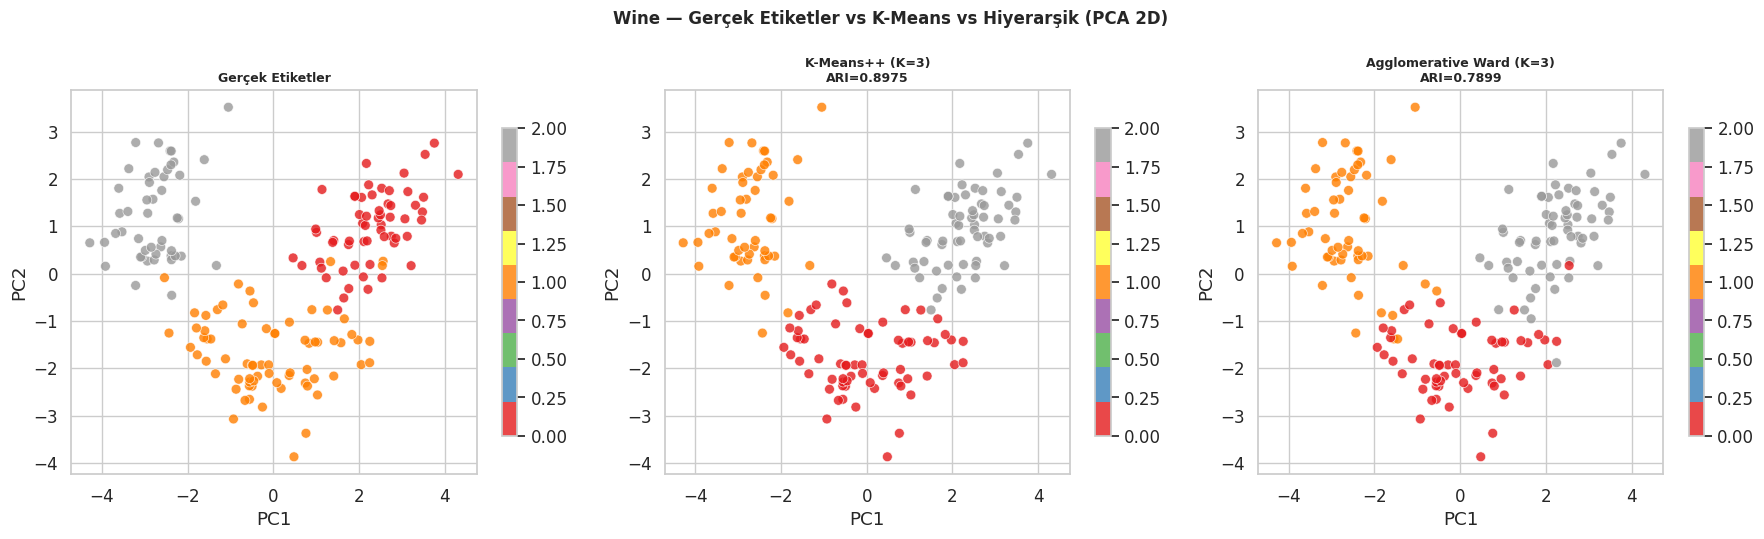

In [15]:
# ─── PCA ile 2D Görselleştirme ───────────────────────────────────────────────

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_sc)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Wine — Gerçek Etiketler vs K-Means vs Hiyerarşik (PCA 2D)',
             fontsize=12, fontweight='bold')

scatter_data = [
    ('Gerçek Etiketler', y_wine),
    ('K-Means++ (K=3)', km_labels_w),
    ('Agglomerative Ward (K=3)', agg_labels),
]

for ax, (title, labels) in zip(axes, scatter_data):
    scatter = ax.scatter(X_wine_2d[:,0], X_wine_2d[:,1],
                         c=labels, cmap='Set1', s=50, alpha=0.8,
                         edgecolors='w', linewidths=0.5)
    if 'Gerçek' not in title:
        ari_t = adjusted_rand_score(y_wine, labels)
        ax.set_title(f'{title}\nARI={ari_t:.4f}', fontweight='bold', fontsize=9)
    else:
        ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    plt.colorbar(scatter, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

Bu grafik, Wine veri setinde gerçek etiketleri, K-Means++ ve Agglomerative Ward sonuçlarını PCA ile 2 boyuta indirgerek yan yana karşılaştırıyor.

ARI Nedir?

Adjusted Rand Index (ARI) — kümelemenin gerçek etiketlerle ne kadar örtüştüğünü ölçer. 1.0 = mükemmel eşleşme, 0 = rastgele, negatif = rastgeleden kötü.

Gerçek Etiketler (Sol)
• 3 net grup görünüyor: gri (sol üst), turuncu (alt-orta), kırmızı (sağ-orta).
• Turuncu ve kırmızı gruplar PCA uzayında kısmen örtüşüyor — bu iki sınıfın ayrıştırılmasının zor olduğuna işaret ediyor.
• Gri grup sol üstte oldukça izole ve kompakt.

K-Means++ — ARI: 0.8975
• Gerçek etiketlerle çok yüksek uyum.
• Gri küme neredeyse mükemmel ayrılmış.
• Turuncu-kırmızı sınırında birkaç hatalı atama var ama genel yapı gerçeğe çok yakın.
• Sınır bölgelerindeki örtüşmeyi varyans minimizasyonuyla makul biçimde çözüyor.

Agglomerative Ward — ARI: 0.7899
• Genel yapıyı yakalıyor ama K-Means++'a göre ~0.11 puan geride.
• Özellikle turuncu-kırmızı geçiş bölgesinde daha fazla hatalı atama göze çarpıyor.
• Gri grup yine iyi ayrılmış — her iki yöntem de izole kümede başarılı.

Genel Çıkarım

| | K-Means++ | Agglomerative Ward |
|--|--|--|
| ARI | 0.8975 | 0.7899 |
| Güçlü yön | Küresel optimizasyon | Hiyerarşik yapı |
| Zayıf yön | Başlangıca duyarlı (++) ile azaltılmış | Sınır bölgelerinde zorlanıyor |

Bu karşılaştırma önemli bir gerçeği ortaya koyuyor: Ward dendrogramı görsel olarak temiz görünse de, gerçek etiketlerle sayısal karşılaştırmada K-Means++ daha başarılı. Hiyerarşik yöntemlerin avantajı K sayısını önceden belirleme zorunluluğu olmaması — ama bu esneklik her zaman daha iyi küme kalitesi anlamına gelmiyor.

---
## 11. Gerçek Veri: Mall Customers (Müşteri Segmentasyonu)

In [16]:
# ─── Mall Customers — Sentetik Oluştur ───────────────────────────────────────
# Gerçek veri: Kaggle Mall Customer Segmentation
# Burada sentetik eşdeğeri oluşturuyoruz

np.random.seed(RANDOM_STATE)

# 5 müşteri segmenti
segments = [
    {'center': [20, 20], 'std': 5,  'n': 50, 'label': 'Genç-Düşük Gelir'},
    {'center': [55, 60], 'std': 8,  'n': 60, 'label': 'Orta Yaş-Orta Gelir'},
    {'center': [25, 85], 'std': 7,  'n': 50, 'label': 'Genç-Yüksek Gelir'},
    {'center': [45, 25], 'std': 6,  'n': 50, 'label': 'Orta Yaş-Düşük Gelir'},
    {'center': [70, 80], 'std': 9,  'n': 40, 'label': 'Yaşlı-Yüksek Gelir'},
]

X_mall_list = []
y_mall_list = []
for i, seg in enumerate(segments):
    pts = np.random.randn(seg['n'], 2) * seg['std'] + seg['center']
    X_mall_list.append(pts)
    y_mall_list.extend([i]*seg['n'])

X_mall = np.vstack(X_mall_list)
y_mall = np.array(y_mall_list)

# Yaş ve Spending Score sınırla
X_mall[:,0] = np.clip(X_mall[:,0], 18, 80)
X_mall[:,1] = np.clip(X_mall[:,1], 1, 100)

df_mall = pd.DataFrame(X_mall, columns=['Yaş', 'Harcama Skoru (1-100)'])
print(f'Mall Müşteri Verisi: {X_mall.shape}')
print(df_mall.describe().round(2))

Mall Müşteri Verisi: (250, 2)
          Yaş  Harcama Skoru (1-100)
count  250.00                 250.00
mean    42.56                  53.31
std     18.23                  27.29
min     18.00                  10.06
25%     23.97                  24.11
50%     44.89                  60.60
75%     56.79                  79.71
max     80.00                  95.80


In [17]:
# ─── Mall Müşteri Segmentasyonu ───────────────────────────────────────────────

scaler_m = StandardScaler()
X_mall_sc = scaler_m.fit_transform(X_mall)

# K=5 K-Means
km_mall = KMeans(n_clusters=5, init='k-means++', n_init=20,
                  random_state=RANDOM_STATE)
mall_labels = km_mall.fit_predict(X_mall_sc)

# Merkezdleri geri ölçeklendir
centers_orig = scaler_m.inverse_transform(km_mall.cluster_centers_)

# Segment analizi
df_mall['Küme'] = mall_labels
segment_summary = df_mall.groupby('Küme').agg(
    N=('Yaş','count'),
    Ortalama_Yas=('Yaş','mean'),
    Ortalama_Harcama=('Harcama Skoru (1-100)','mean')
).round(1)

print('Mall Müşteri Segmentleri:')
print(segment_summary)

Mall Müşteri Segmentleri:
       N  Ortalama_Yas  Ortalama_Harcama
Küme                                    
0     60          53.1              62.1
1     48          26.4              84.6
2     51          20.6              19.7
3     49          45.4              25.5
4     42          69.3              78.3


In [18]:
# ─── Mall Segmentasyon Görselleştirmesi (Plotly) ─────────────────────────────

colors_mall = ['#E74C3C','#2196F3','#2ECC71','#FF9800','#9B59B6']
seg_names   = ['Segment 0','Segment 1','Segment 2','Segment 3','Segment 4']

fig = go.Figure()
for k in range(5):
    mask = mall_labels == k
    fig.add_trace(go.Scatter(
        x=X_mall[mask,0], y=X_mall[mask,1],
        mode='markers',
        marker=dict(color=colors_mall[k], size=8, opacity=0.75),
        name=f'Segment {k} (N={mask.sum()})'
    ))

# Merkezler
fig.add_trace(go.Scatter(
    x=centers_orig[:,0], y=centers_orig[:,1],
    mode='markers',
    marker=dict(symbol='star', size=20, color='black',
                line=dict(color='white', width=1)),
    name='Merkezdler'
))

fig.update_layout(
    title='Mall Müşteri Segmentasyonu — K-Means (K=5)',
    xaxis_title='Yaş', yaxis_title='Harcama Skoru',
    height=470, template='plotly_white'
)
fig.show()

Bu grafik, Mall Müşteri veri seti üzerinde K-Means (K=5) ile yapılmış müşteri segmentasyonunu gösteriyor. Eksenler Yaş ve Harcama Skoru, yıldızlar ise küme merkezleri.

Segment Profilleri

🔵 Segment 1 — Genç & Yüksek Harcayan (N=48)
• Yaş: ~18–40, Harcama: ~75–90
• Merkez: (~25, 83)
• Genç, alışverişe düşkün müşteriler. Sadakat programları ve trend ürünler için ideal hedef kitle.

🟣 Segment 4 — Orta Yaş & Yüksek Harcayan (N=42)
• Yaş: ~40–80, Harcama: ~60–95
• Merkez: (~70, 79)
• Daha olgun, satın alma gücü yüksek müşteriler. Premium ürün ve hizmetler için uygun.

🔴 Segment 0 — Orta Yaş & Orta Harcayan (N=60)
• Yaş: ~40–70, Harcama: ~40–80
• Merkez: (~52, 62)
• En kalabalık grup, geniş bir dağılım gösteriyor. Genel kampanyalar için ana kitle.

🟡 Segment 3 — Orta Yaş & Düşük Harcayan (N=49)
• Yaş: ~35–70, Harcama: ~15–40
• Merkez: (~49, 25)
• Harcama skoru düşük ama yaş aralığı geniş. İndirim ve promosyonlarla aktive edilebilir.

🟢 Segment 2 — Genç & Düşük Harcayan (N=51)
• Yaş: ~15–35, Harcama: ~10–30
• Merkez: (~21, 20)
• Genç ama harcama kapasitesi kısıtlı. Bütçe dostu ürünler veya uzun vadeli sadakat stratejileri uygun.

Genel Çıkarım

Veri, yaş ve harcama eksenlerinde 5 doğal segmente güzel ayrılmış — küme yapıları oldukça kompakt ve örtüşme minimal. Bu, K=5'in bu veri seti için iyi bir seçim olduğuna işaret ediyor.

Pazarlama açısından en değerli segmentler Segment 1 ve 4 (yüksek harcama), en büyük potansiyel taşıyan segment ise Segment 3 — doğru kampanyayla harcama skorları artırılabilir.

---
## 12. Küme Değerlendirme Metrikleri

In [19]:
# ─── Kapsamlı Küme Değerlendirme — Iris & Wine ───────────────────────────────

eval_rows = []

for ds_name, X_ds, y_ds, K_ds in [
    ('Iris',  X_iris_sc,  y_iris, 3),
    ('Wine',  X_wine_sc,  y_wine, 3),
    ('Mall',  X_mall_sc,  y_mall, 5),
]:
    for method, model in [
        ('K-Means++', KMeans(n_clusters=K_ds, init='k-means++', n_init=10, random_state=RANDOM_STATE)),
        ('Agglomerative Ward', AgglomerativeClustering(n_clusters=K_ds, linkage='ward')),
        ('Agglomerative Avg',  AgglomerativeClustering(n_clusters=K_ds, linkage='average')),
        ('Agglomerative Comp', AgglomerativeClustering(n_clusters=K_ds, linkage='complete')),
    ]:
        labels_m = model.fit_predict(X_ds)
        eval_rows.append({
            'Veri'   : ds_name,
            'Yöntem' : method,
            'ARI'    : round(adjusted_rand_score(y_ds, labels_m), 4),
            'NMI'    : round(normalized_mutual_info_score(y_ds, labels_m), 4),
            'Silhouette': round(silhouette_score(X_ds, labels_m), 4),
            'Calinski-H': round(calinski_harabasz_score(X_ds, labels_m), 1),
            'Davies-B'  : round(davies_bouldin_score(X_ds, labels_m), 4),
        })

df_eval = pd.DataFrame(eval_rows)
print('Kümeleme Değerlendirme Metrikleri:')
print('  ARI/NMI: Gerçek etiketle uyum (0-1, yüksek iyi)')
print('  Silhouette: Küme sıkılığı (-1 ile 1, yüksek iyi)')
print('  Calinski-H: Büyük değer iyi')
print('  Davies-B: Küçük değer iyi')
print()
display(df_eval)

Kümeleme Değerlendirme Metrikleri:
  ARI/NMI: Gerçek etiketle uyum (0-1, yüksek iyi)
  Silhouette: Küme sıkılığı (-1 ile 1, yüksek iyi)
  Calinski-H: Büyük değer iyi
  Davies-B: Küçük değer iyi



,Veri,Yöntem,ARI,NMI,Silhouette,Calinski-H,Davies-B
0,Iris,K-Means++,0.6201,0.6595,0.4599,241.9,0.8336
1,Iris,Agglomerative Ward,0.6153,0.6755,0.4467,222.7,0.8035
2,Iris,Agglomerative Avg,0.5621,0.7131,0.4803,149.0,0.5753
3,Iris,Agglomerative Comp,0.5726,0.6530,0.4496,213.1,0.7584
4,Wine,K-Means++,0.8975,0.8759,0.2849,70.9,1.3892
5,Wine,Agglomerative Ward,0.7899,0.7865,0.2774,67.6,1.4186
6,Wine,Agglomerative Avg,-0.0054,0.0184,0.1575,4.0,1.0299
7,Wine,Agglomerative Comp,0.5771,0.6144,0.2038,49.0,1.8961
8,Mall,K-Means++,0.8626,0.8756,0.5770,666.7,0.6197
9,Mall,Agglomerative Ward,0.8521,0.8885,0.5699,647.0,0.6288


In [20]:
# ─── Altair: Karşılaştırma Isı Haritası ──────────────────────────────────────

df_pivot = df_eval.copy()
df_pivot['Model'] = df_pivot['Veri'] + ' | ' + df_pivot['Yöntem']

df_long = df_pivot[['Model','ARI','NMI','Silhouette']].melt(
    id_vars='Model', var_name='Metrik', value_name='Değer'
)

chart_e = alt.Chart(df_long).mark_rect().encode(
    x=alt.X('Metrik:N'),
    y=alt.Y('Model:N'),
    color=alt.Color('Değer:Q',
        scale=alt.Scale(scheme='greenblue', domain=[0,1])
    ),
    tooltip=['Model:N','Metrik:N',
             alt.Tooltip('Değer:Q', format='.4f')]
).properties(
    width=250, height=380,
    title='Kümeleme Metrikleri — Isı Haritası'
)

text_e = chart_e.mark_text(fontSize=9).encode(
    text=alt.Text('Değer:Q', format='.3f'),
    color=alt.condition(
        alt.datum.Değer > 0.6, alt.value('white'), alt.value('black')
    )
)
(chart_e + text_e).configure_title(fontSize=12).show()

alt.LayerChart(...)

---
## 13. Özet ve Sonraki Adımlar

### Bu Derste Öğrendiklerimiz:

| Konu | Ana Çıkarım |
|------|-------------|
| K-Means | Inertia minimize et, K merkez bul |
| Lloyd Algoritması | Ata → Güncelle → Tekrar. Yerel minimum riski var |
| K-Means++ | Uzaklık orantılı başlangıç → Daha kararlı |
| Elbow Method | Inertia vs K — 'kırılma' noktası |
| Silhouette | İç küme sıkılığı — 1'e yakın iyi |
| Mini-Batch | Büyük veri için N>100K |
| K-Means Sınırı | Küresel şekil varsayımı — İç içe / ay şekli başarısız |
| Hiyerarşik | Dendrogram → K'yı sonradan seç |
| Ward Linkage | En kompakt kümeler — en çok önerilen |
| ARI / NMI | Gerçek etiket varsa küme kalitesi ölç |
| Silhouette | Etiket gerekmez — dahili metrik |

### Sonraki Hafta: DBSCAN + Küme Değerlendirme

### Kaynaklar:
- Géron — Hands-On ML, Bölüm 9: Unsupervised Learning Techniques
- https://scikit-learn.org/stable/modules/clustering.html
- https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation

In [21]:
print('='*62)
print(' K-MEANS & HİYERARŞİK KÜMELEME — DERS ÖZET')
print('='*62)
print()
print('Iris (K=3):')
iris_rows = df_eval[df_eval['Veri']=='Iris'][['Yöntem','ARI','Silhouette']]
print(iris_rows.to_string(index=False))
print()
print('Wine (K=3):')
wine_rows = df_eval[df_eval['Veri']=='Wine'][['Yöntem','ARI','Silhouette']]
print(wine_rows.to_string(index=False))
print()
print(f'K-Means++ vs Rastgele Başlangıç:')
print(f'  Rastgele: Ort={np.mean(inertia_random):.2f}  Std={np.std(inertia_random):.2f}')
print(f'  K-Means++: Ort={np.mean(inertia_pp):.2f}  Std={np.std(inertia_pp):.2f}')
print()
print(' Sonraki Ders: DBSCAN + Küme Değerlendirme')
print('='*62)

 K-MEANS & HİYERARŞİK KÜMELEME — DERS ÖZET

Iris (K=3):
            Yöntem    ARI  Silhouette
         K-Means++ 0.6201      0.4599
Agglomerative Ward 0.6153      0.4467
 Agglomerative Avg 0.5621      0.4803
Agglomerative Comp 0.5726      0.4496

Wine (K=3):
            Yöntem     ARI  Silhouette
         K-Means++  0.8975      0.2849
Agglomerative Ward  0.7899      0.2774
 Agglomerative Avg -0.0054      0.1575
Agglomerative Comp  0.5771      0.2038

K-Means++ vs Rastgele Başlangıç:
  Rastgele: Ort=156.18  Std=24.30
  K-Means++: Ort=150.83  Std=20.93

 Sonraki Ders: DBSCAN + Küme Değerlendirme
